In [15]:
# Load in packages
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import random
import ast
import itertools

In [3]:
hepg2_path = "/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/HepG2_all-data.feather"

hepg2 = pl.read_ipc(hepg2_path)

# get the binding columns
subset_cols = hepg2.columns[1:631]

# unique binding pattern df
hepg2_unique = hepg2.unique(subset=subset_cols, keep="first")

# PPI pairs and their shap correlations

hepg2_final = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/02_ppi_correlation_plots/data/hepg2_ubp_ppi_shap_correlations.csv')

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


## RBP-RBP Pair Selection

In [4]:
# Extracting protein names

cols = hepg2.columns  

# filter for columns ending with "_1_binding"
binding_cols = [c for c in cols if c.endswith("_1_binding")]

# extract protein names by removing the suffix
proteins = [c.replace("_1_binding", "") for c in binding_cols]

print(proteins)

['AGGF1', 'AKAP1', 'AQR', 'BCCIP', 'BCLAF1', 'BUD13', 'CDC40', 'CSTF2', 'CSTF2T', 'DDX3X', 'DDX52', 'DDX55', 'DDX59', 'DDX6', 'DGCR8', 'DHX30', 'DKC1', 'DROSHA', 'EFTUD2', 'EIF3D', 'EIF3H', 'EXOSC5', 'FAM120A', 'FASTKD2', 'FKBP4', 'FTO', 'FUBP3', 'FUS', 'FXR2', 'G3BP1', 'GRSF1', 'GRWD1', 'GTF2F1', 'HLTF', 'HNRNPA1', 'HNRNPC', 'HNRNPK', 'HNRNPL', 'HNRNPM', 'HNRNPU', 'HNRNPUL1', 'IGF2BP1', 'IGF2BP3', 'ILF3', 'KHSRP', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MATR3', 'NCBP2', 'NIP7', 'NKRF', 'NOL12', 'NOLC1', 'NSUN2', 'PABPN1', 'PCBP1', 'PCBP2', 'POLR2G', 'PPIG', 'PRPF4', 'PRPF8', 'PTBP1', 'QKI', 'RBFOX2', 'RBM15', 'RBM22', 'RBM5', 'RPS3', 'SAFB', 'SDAD1', 'SF3A3', 'SF3B4', 'SFPQ', 'SLTM', 'SMNDC1', 'SND1', 'SRSF1', 'SRSF7', 'SRSF9', 'SSB', 'STAU2', 'SUB1', 'SUGP2', 'SUPV3L1', 'TAF15', 'TARDBP', 'TBRG4', 'TIA1', 'TIAL1', 'TRA2A', 'TROVE2', 'U2AF1', 'U2AF2', 'UCHL5', 'UPF1', 'UTP18', 'WDR43', 'XPO5', 'XRCC6', 'XRN2', 'YBX3', 'ZC3H11A', 'ZNF800']


In [6]:
# Read in dataframe of existing PPIs to exclude them downstream
# Clean the PPI dataframe to get rid of duplicated PPIs

ppi_hepg2 = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/PPI_table_hepg2.csv')

ppi_hepg2["pair"] = ppi_hepg2.apply(
    lambda row: tuple(sorted([row["Prey"], row["Bait"]])),
    axis=1
)

# Drop duplicates
ppi_hepg2_unique = ppi_hepg2.drop_duplicates("pair")

# Convert existing PPI pairs into a set of frozen sets for fast lookup
ppi_pairs_hepg2 = {frozenset([row[0], row[1]]) for row in zip(ppi_hepg2_unique["Bait"].to_list(),
                                                       ppi_hepg2_unique["Prey"].to_list())}

In [9]:
# Selecting random protein pairs and removing those with PPI

# make all possible unordered pairs of proteins
all_pairs = list(itertools.combinations(proteins, 2))

# shuffle to randomize
random.shuffle(all_pairs)

# filter out pairs of PPIs
unique_pairs = [
    pair for pair in all_pairs
    if frozenset(pair) not in ppi_pairs_hepg2
]

# select 3000 random unique pairs
selected_pairs = unique_pairs[:3000]

print(len(selected_pairs))

print(selected_pairs[:10])  # show a preview

3000
[('BUD13', 'SUB1'), ('NOLC1', 'SRSF7'), ('DDX59', 'LIN28B'), ('DHX30', 'QKI'), ('FTO', 'LARP4'), ('STAU2', 'ZC3H11A'), ('HNRNPUL1', 'PRPF4'), ('U2AF1', 'UPF1'), ('DDX3X', 'DDX55'), ('DDX55', 'SUB1')]


In [10]:
# Put the pairs into a dataframe with protein1, protein2, and pair

rbp_pairs = pd.DataFrame({
    "protein1": [p1 for p1, p2 in selected_pairs],
    "protein2": [p2 for p1, p2 in selected_pairs],
    "pair": [(p1, p2) for p1, p2 in selected_pairs],  # <-- tuple, not string
})

print(rbp_pairs.head())

  protein1 protein2             pair
0    BUD13     SUB1    (BUD13, SUB1)
1    NOLC1    SRSF7   (NOLC1, SRSF7)
2    DDX59   LIN28B  (DDX59, LIN28B)
3    DHX30      QKI     (DHX30, QKI)
4      FTO    LARP4     (FTO, LARP4)


In [11]:
# hepg2 Unique Binding Sites Correlations Dataframe

positions = [1, 2, 3, 4, 5, 6]

# create empty results dataframe with explicit types
results_hepg2 = pl.DataFrame(
    {
        "Protein1": pl.Series(dtype=pl.Utf8),
        "Protein2": pl.Series(dtype=pl.Utf8),
        "Position": pl.Series(dtype=pl.Int64),
        "Pearson_Corr": pl.Series(dtype=pl.Float64),
        "Pearson_P": pl.Series(dtype=pl.Float64),
        "Spearman_Corr": pl.Series(dtype=pl.Float64),
        "Spearman_P": pl.Series(dtype=pl.Float64),
        "n": pl.Series(dtype=pl.Int64),
    }
)


for protein1, protein2 in rbp_pairs["pair"]:
    for pos in positions:
        # dynamic column names
        bind1 = f"{protein1}_{pos}_binding"
        bind2 = f"{protein2}_{pos}_binding"
        shap1 = f"{protein1}_{pos}_shap"
        shap2 = f"{protein2}_{pos}_shap"

        # filter valid rows
        subset = hepg2_unique.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))
        
        if subset.height in [0, 1]:
            # print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
            continue

        # extract shap values as lists
        x = subset[shap1].to_list()
        y = subset[shap2].to_list()
        n_points = len(x)

        # calculate Pearson correlation
        pearson_corr, pearson_pval = pearsonr(x, y)

        # calculate Spearman correlation
        spearman_corr, spearman_pval = spearmanr(x, y)
    
        # append results
        results_hepg2 = results_hepg2.vstack(
            pl.DataFrame(
                {
                    "Protein1": [protein1],
                    "Protein2": [protein2],
                    "Position": [pos],
                    "Pearson_Corr": [pearson_corr],
                    "Pearson_P": [pearson_pval],
                    "Spearman_Corr": [spearman_corr],
                    "Spearman_P": [spearman_pval],
                    "n": [n_points],
                }
            )
        )
        
results_hepg2

results_hepg2_final = results_hepg2.to_pandas()

results_hepg2_final.to_csv('hepg2_ubp_non_ppi_shap_corrs.csv', index = False)

/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


In [23]:
hepg2_results = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/hepg2_ubp_non_ppi_shap_corrs.csv')

# hepg2_results

{1: 60, 2: 61, 3: 52, 4: 52, 5: 52, 6: 56}
Position 1: sampled 60 rows


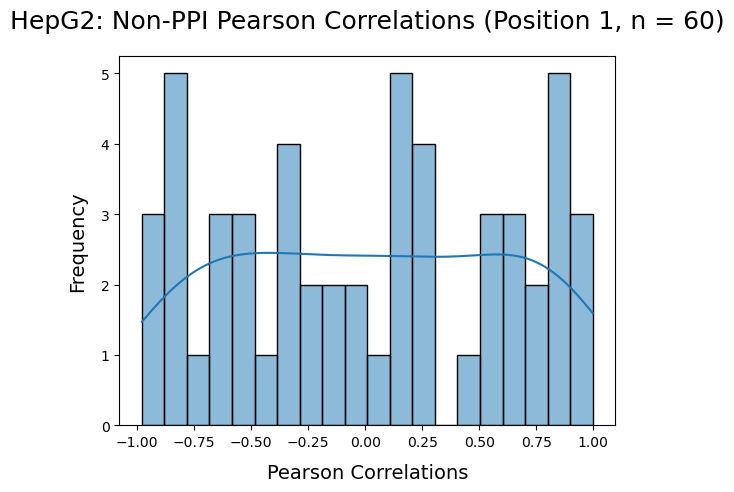

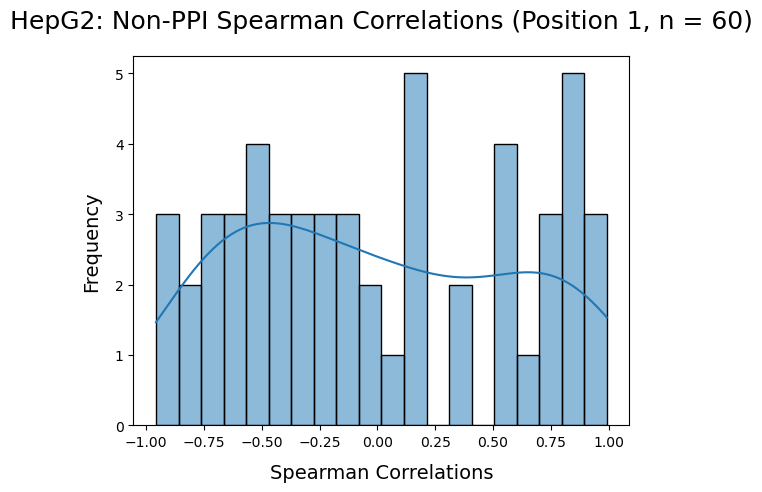

Plot for position 1
Position 2: sampled 61 rows


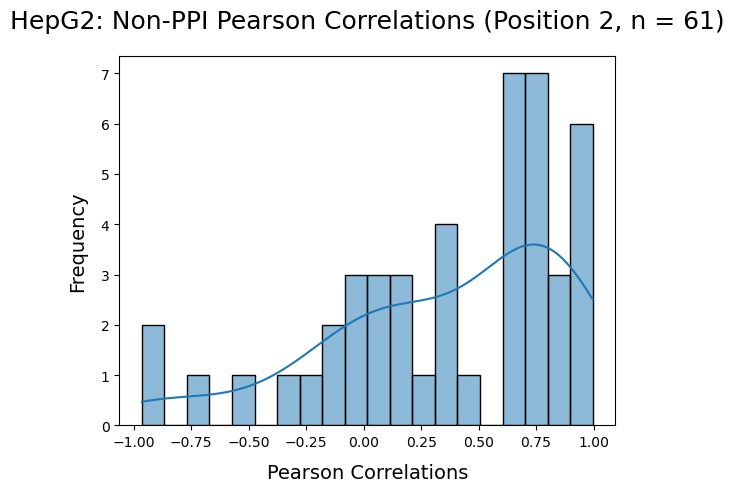

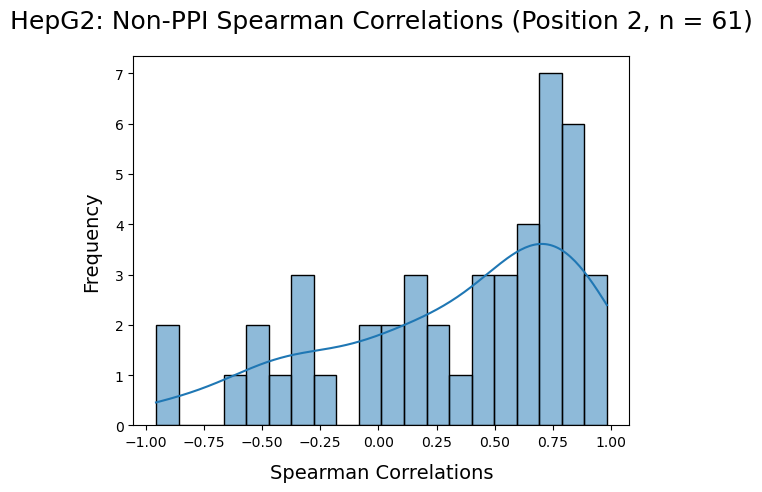

Plot for position 2
Position 3: sampled 52 rows


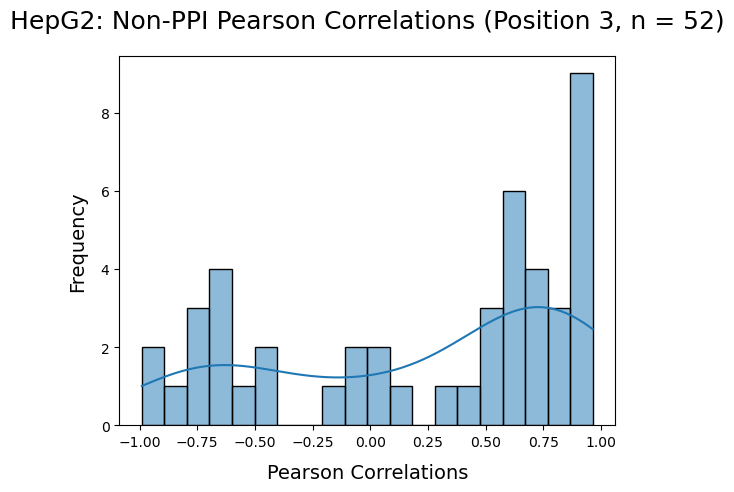

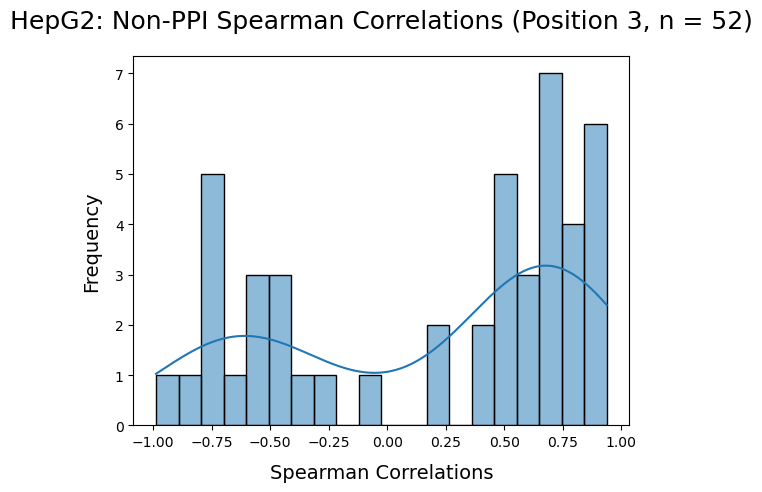

Plot for position 3
Position 4: sampled 52 rows


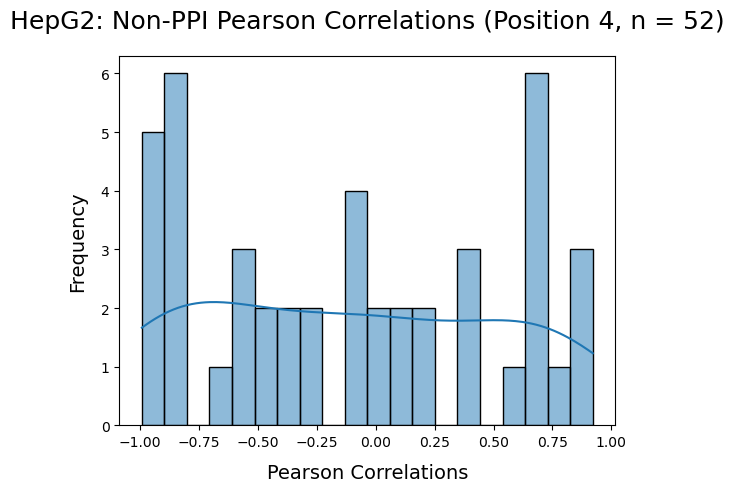

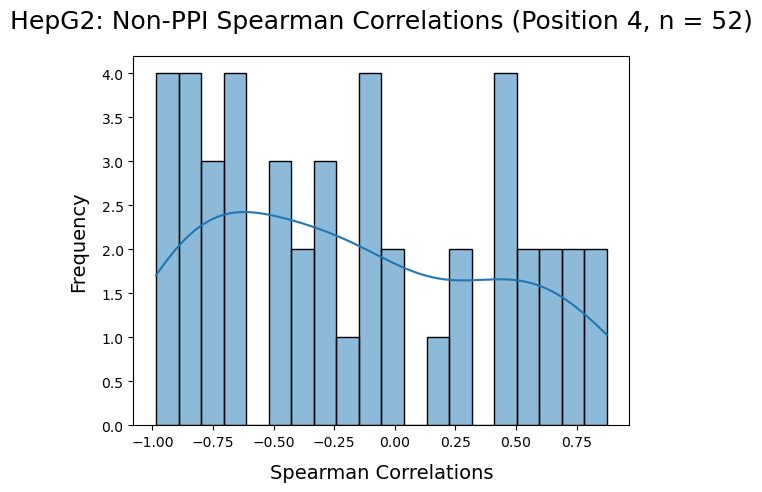

Plot for position 4
Position 5: sampled 52 rows


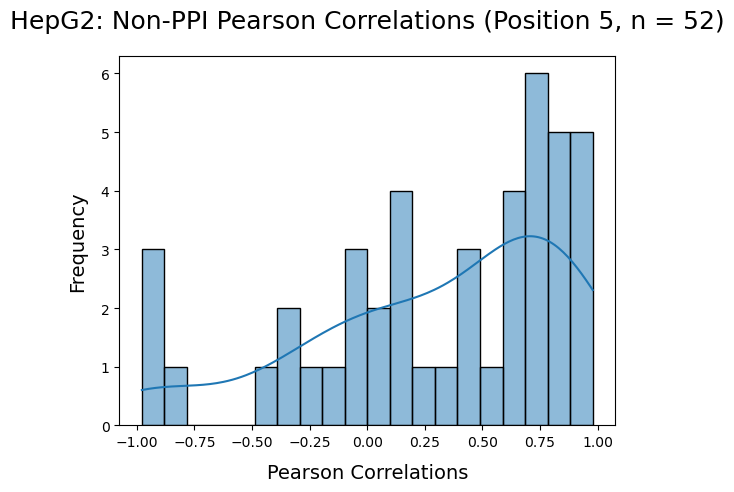

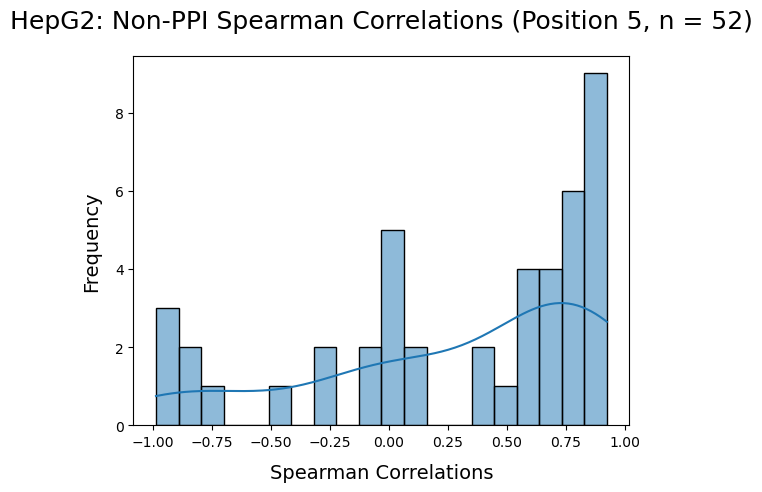

Plot for position 5
Position 6: sampled 56 rows


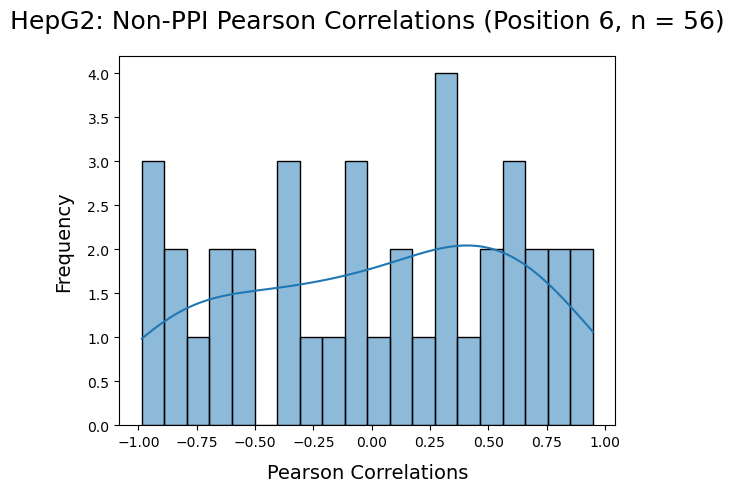

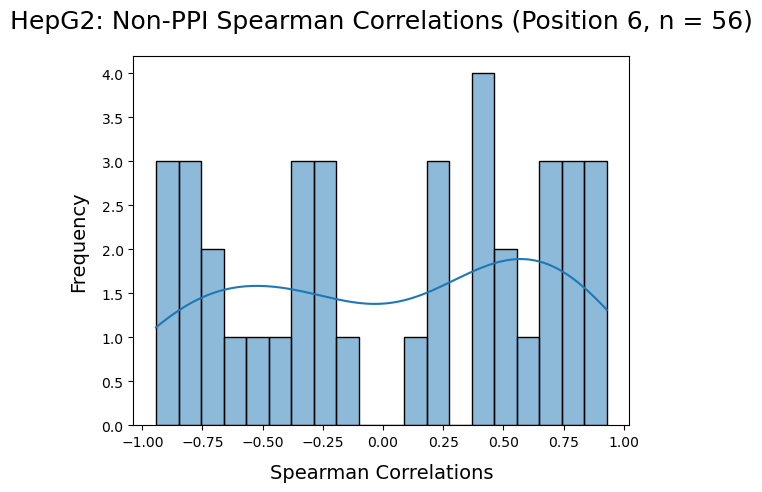

Plot for position 6


In [24]:
# HepG2 Distribution of Pearson and Spearman correlations per position

samples = [60, 61, 52, 52, 52, 56]
positions = [1, 2, 3, 4, 5, 6]
sample_map = dict(zip(positions, samples))
print(sample_map)

# The new df
all_samples = []

for pos in positions:
    
    # Get the coors from the right position
    subset = hepg2_results[(hepg2_results["Position"] == pos) & (hepg2_results["n"] > 30)]
    
    # Figure out how many samples needed
    n_samples = sample_map[pos]
    
    # From the positon subset, grab the right sample size
    final_samples = subset.sample(n=n_samples, random_state=42)
    print(f"Position {pos}: sampled {n_samples} rows")
    
    # Append output to a new df for the all distributions plot
    all_samples.append(final_samples)
    
    # Plot Pearson and Spearman Correlation Distributions
    sns.histplot(final_samples["Pearson_Corr"], kde = True, bins = 20)
    plt.title(f"HepG2: Non-PPI Pearson Correlations (Position {pos}, n = {n_samples})", fontsize = 18, pad = 20)
    plt.xlabel("Pearson Correlations", fontsize = 14, labelpad = 10)
    plt.ylabel("Frequency", fontsize = 14, labelpad = 10)
    plt.show()
    
    sns.histplot(final_samples["Spearman_Corr"], kde = True, bins = 20)
    plt.title(f"HepG2: Non-PPI Spearman Correlations (Position {pos}, n = {n_samples})", fontsize = 18, pad = 20)
    plt.xlabel("Spearman Correlations", fontsize = 14, labelpad = 10)
    plt.ylabel("Frequency", fontsize = 14, labelpad = 10)
    plt.show()
    print(f"Plot for position {pos}")
    
combined_samples = pd.concat(all_samples, ignore_index=True)

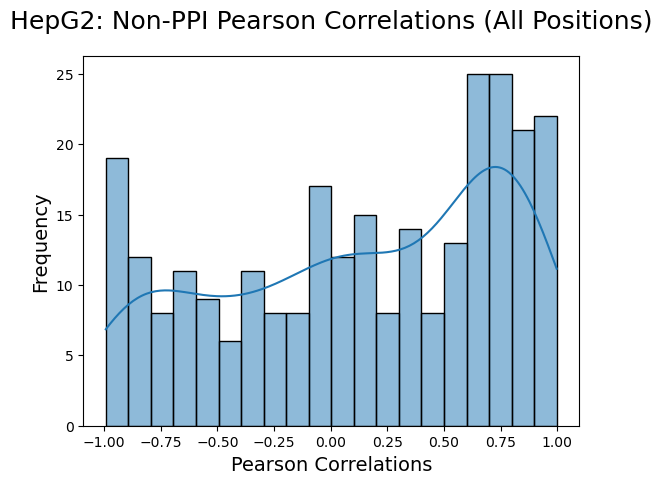

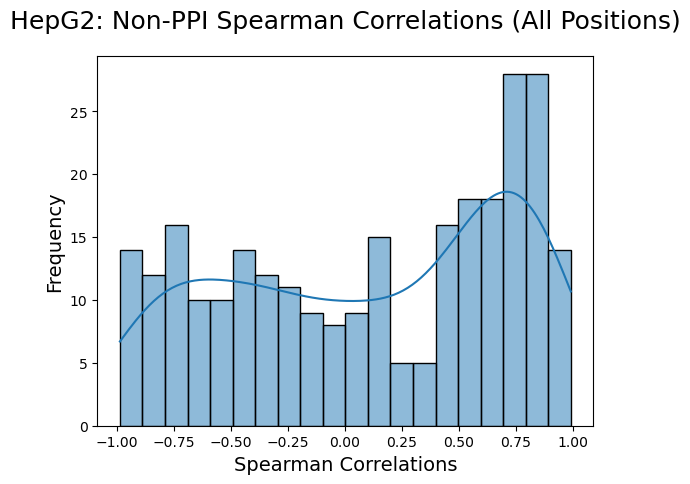

In [25]:
# All positons

sns.histplot(data = combined_samples, x = "Pearson_Corr", kde = True, bins = 20)
plt.title(f"HepG2: Non-PPI Pearson Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Pearson Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

sns.histplot(data = combined_samples, x = "Spearman_Corr", kde = True, bins = 20)
plt.title(f"HepG2: Non-PPI Spearman Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Spearman Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

## K562

In [19]:
k562_path = "/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/K562_all-data.feather"

# big dataframe
k562 = pl.read_ipc(k562_path)

# get the binding columns
subset_cols = k562.columns[1:835]

# unique based on them -> unique binding patterns
k562_unique = k562.unique(subset=subset_cols, keep="first")

# Heatmap of PPI pairs and their shap correlations

k562_final = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/k562_ubp_ppi_shap_correlations.csv')

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


# RBP-RBP Pair Selection

In [20]:
# Extracting protein names

cols = k562.columns  

# filter for columns ending with "_1_binding"
binding_cols = [c for c in cols if c.endswith("_1_binding")]

# extract protein names by removing the suffix
proteins = [c.replace("_1_binding", "") for c in binding_cols]

print(proteins)

['AARS', 'AATF', 'ABCF1', 'ADAT1', 'AGGF1', 'AKAP1', 'AKAP8L', 'APEX1', 'APOBEC3C', 'AQR', 'BUD13', 'CPEB4', 'CPSF6', 'CSTF2T', 'DDX1', 'DDX21', 'DDX24', 'DDX3X', 'DDX42', 'DDX43', 'DDX47', 'DDX51', 'DDX52', 'DDX55', 'DDX6', 'DGCR8', 'DHX30', 'DROSHA', 'EEF2', 'EFTUD2', 'EIF3G', 'EIF4E', 'EIF4G2', 'ELAC2', 'ELAVL1', 'EWSR1', 'EXOSC10', 'EXOSC5', 'FAM120A', 'FASTKD2', 'FMR1', 'FTO', 'FUS', 'FXR1', 'FXR2', 'GARS', 'GEMIN5', 'GNL3', 'GPKOW', 'GRWD1', 'GTF2F1', 'HLTF', 'HNRNPA1', 'HNRNPC', 'HNRNPK', 'HNRNPL', 'HNRNPM', 'HNRNPU', 'HNRNPUL1', 'IGF2BP1', 'IGF2BP2', 'ILF3', 'KHDRBS1', 'KHSRP', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MATR3', 'MBNL1', 'METAP2', 'METTL1', 'MORC2', 'MTPAP', 'NCBP2', 'NIPBL', 'NOLC1', 'NONO', 'NPM1', 'NSUN2', 'PABPC4', 'PCBP1', 'PHF6', 'PPIL4', 'PRPF8', 'PTBP1', 'PUM1', 'PUM2', 'PUS1', 'QKI', 'RBFOX2', 'RBM15', 'RBM22', 'RNF187', 'RPS10', 'RPS11', 'RPS3', 'RPS6', 'RYBP', 'SAFB', 'SAFB2', 'SBDS', 'SDAD1', 'SERBP1', 'SF3B1', 'SF3B4', 'SLBP', 'SLTM', 'SMNDC1', 'SND1', '

In [21]:
# Load in PPIs to exclude them later
# Clean the PPI dataframe to get rid of duplicated PPIs

ppi_k562 = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/PPI_table_k562.csv')

ppi_k562["pair"] = ppi_k562.apply(
    lambda row: tuple(sorted([row["Prey"], row["Bait"]])),
    axis=1
)

# Drop duplicates
ppi_k562_unique = ppi_k562.drop_duplicates("pair")

# Convert existing PPI pairs into a set of frozen sets for fast lookup
ppi_pairs_k562 = {frozenset([row[0], row[1]]) for row in zip(ppi_k562_unique["Bait"].to_list(),
                                                       ppi_k562_unique["Prey"].to_list())}

In [22]:
# Selecting random protein pairs and removing those with PPI

# make all possible unordered pairs of proteins
all_pairs = list(itertools.combinations(proteins, 2))

# shuffle to randomize
random.shuffle(all_pairs)

# filter out pairs already in the frozen set
unique_pairs = [
    pair for pair in all_pairs
    if frozenset(pair) not in ppi_pairs_hepg2
]

# select 3000 random unique pairs
selected_pairs = unique_pairs[:3000]

print(len(selected_pairs))

print(selected_pairs[:10])  # show a preview

3000
[('RYBP', 'XRCC6'), ('HLTF', 'SAFB2'), ('DDX42', 'DDX43'), ('PUS1', 'ZRANB2'), ('CSTF2T', 'DDX3X'), ('IGF2BP2', 'RBM22'), ('HNRNPC', 'RBFOX2'), ('LARP4', 'TBRG4'), ('PABPC4', 'RBM22'), ('ADAT1', 'ZNF622')]


In [23]:
# Put the pairs into a dataframe with protein1, protein2, and pair

rbp_pairs = pd.DataFrame({
    "protein1": [p1 for p1, p2 in selected_pairs],
    "protein2": [p2 for p1, p2 in selected_pairs],
    "pair": [(p1, p2) for p1, p2 in selected_pairs],  # <-- tuple, not string
})

print(rbp_pairs.head())

  protein1 protein2             pair
0     RYBP    XRCC6    (RYBP, XRCC6)
1     HLTF    SAFB2    (HLTF, SAFB2)
2    DDX42    DDX43   (DDX42, DDX43)
3     PUS1   ZRANB2   (PUS1, ZRANB2)
4   CSTF2T    DDX3X  (CSTF2T, DDX3X)


In [24]:
# K562 Unique Binding Sites Correlations Dataframe

positions = [1, 2, 3, 4, 5, 6]

# create empty results dataframe with explicit types
results_k562 = pl.DataFrame(
    {
        "Protein1": pl.Series(dtype=pl.Utf8),
        "Protein2": pl.Series(dtype=pl.Utf8),
        "Position": pl.Series(dtype=pl.Int64),
        "Pearson_Corr": pl.Series(dtype=pl.Float64),
        "Pearson_P": pl.Series(dtype=pl.Float64),
        "Spearman_Corr": pl.Series(dtype=pl.Float64),
        "Spearman_P": pl.Series(dtype=pl.Float64),
        "n": pl.Series(dtype=pl.Int64),
    }
)


for protein1, protein2 in rbp_pairs["pair"]:
    for pos in positions:
        # dynamic column names
        bind1 = f"{protein1}_{pos}_binding"
        bind2 = f"{protein2}_{pos}_binding"
        shap1 = f"{protein1}_{pos}_shap"
        shap2 = f"{protein2}_{pos}_shap"

        # filter valid rows
        subset = k562_unique.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))
        
        if subset.height in [0, 1]:
            # print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
            continue

        # extract shap values as lists
        x = subset[shap1].to_list()
        y = subset[shap2].to_list()
        n_points = len(x)

        # calculate Pearson correlation
        pearson_corr, pearson_pval = pearsonr(x, y)

        # calculate Spearman correlation
        spearman_corr, spearman_pval = spearmanr(x, y)
    
        # append results
        results_k562 = results_k562.vstack(
            pl.DataFrame(
                {
                    "Protein1": [protein1],
                    "Protein2": [protein2],
                    "Position": [pos],
                    "Pearson_Corr": [pearson_corr],
                    "Pearson_P": [pearson_pval],
                    "Spearman_Corr": [spearman_corr],
                    "Spearman_P": [spearman_pval],
                    "n": [n_points],
                }
            )
        )
        
#results_k562

results_k562_final = results_k562.to_pandas()

results_k562_final.to_csv('k562_ubp_non_ppi_shap_corrs.csv', index = False)

/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/apps/software/standard/core/jupyterlab/3.6.3-py3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


In [27]:
# Read in the results csv for easy reloading

k562_results = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/k562_ubp_non_ppi_shap_corrs.csv')

# k562_results

In [44]:
# K562 Distribution of Pearson and Spearman correlations per position

samples = [91, 98, 106, 84, 99, 69]
positions = [1, 2, 3, 4, 5, 6]
sample_map = dict(zip(positions, samples))
print(sample_map)

# The new df
all_samples = []

for pos in positions:
    
    # Get the coors from the right position
    subset = k562_results[(k562_results["Position"] == pos) & (k562_results["n"] > 30)]
    
    
    # Figure out how many samples needed
    n_samples = sample_map[pos]


    # From the positon subset, grab the right sample size
    final_samples = subset.sample(n=n_samples, random_state=42)
    print(f"Position {pos}: sampled {n_samples} rows")
    
    
    # Append output to a new df for the all distributions plot
    all_samples.append(final_samples)
    
    # Plot Pearson and Spearman Correlation Distributions
    sns.histplot(final_samples["Pearson_Corr"], kde = True, bins = 20)
    plt.title(f"K562: Non-PPI Pearson Correlations (Position {pos}, n = {n_samples})", fontsize = 18, pad = 20)
    plt.xlabel("Pearson Correlations", fontsize = 14, labelpad = 10)
    plt.ylabel("Frequency", fontsize = 14, labelpad = 10)
    plt.show()
    
    sns.histplot(final_samples["Spearman_Corr"], kde = True, bins = 20)
    plt.title(f"K562: Non-PPI Spearman Correlations (Position {pos}, n = {n_samples})", fontsize = 18, pad = 20)
    plt.xlabel("Spearman Correlations", fontsize = 14, labelpad = 10)
    plt.ylabel("Frequency", fontsize = 14, labelpad = 10)
    plt.show()
    print(f"Plot for position {pos}")
    
combined_samples2 = pd.concat(all_samples, ignore_index=True)

{1: 91, 2: 98, 3: 106, 4: 84, 5: 99, 6: 69}
Position 1: sampled 91 rows
Position 2: sampled 98 rows
Position 3: sampled 106 rows
Position 4: sampled 84 rows
Position 5: sampled 99 rows
Position 6: sampled 69 rows


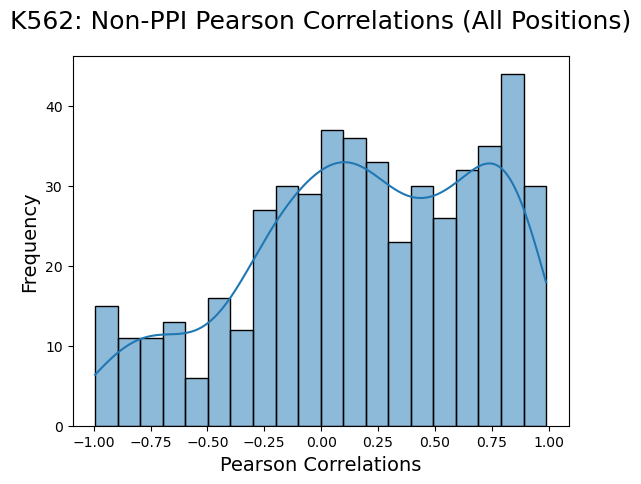

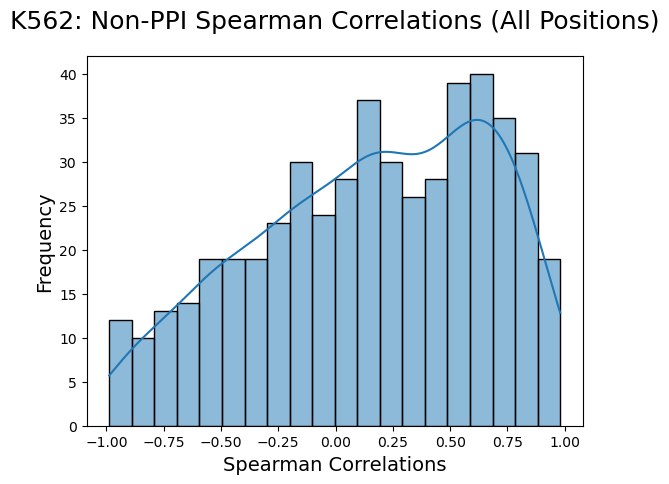

In [46]:
# All positons

sns.histplot(data = combined_samples2, x = "Pearson_Corr", kde = True, bins = 20)
plt.title(f"K562: Non-PPI Pearson Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Pearson Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

sns.histplot(data = combined_samples2, x = "Spearman_Corr", kde = True, bins = 20)
plt.title(f"K562: Non-PPI Spearman Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Spearman Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

In [30]:
print(combined_samples2.shape)

(880, 8)


## K-S Tests

In [22]:
combined_samples

,Protein1,Protein2,Position,Pearson_Corr,Pearson_P,Spearman_Corr,Spearman_P,n
0,CSTF2T,FUS,1,-0.786198,9.880441e-14,-0.862040,9.180715e-19,60
1,NIP7,SUB1,1,0.984372,9.430211e-29,0.774511,1.158976e-08,38
2,NOLC1,SDAD1,1,-0.224469,1.761491e-05,-0.346935,1.363660e-11,359
3,SF3A3,SUB1,1,-0.069808,4.923391e-01,0.041290,6.848970e-01,99
4,PCBP2,TAF15,1,NaN,NaN,NaN,NaN,33
...,...,...,...,...,...,...,...,...
875,DDX51,HNRNPUL1,6,NaN,NaN,NaN,NaN,44
876,FXR1,RPS3,6,0.968089,2.728002e-102,0.853382,4.068559e-49,169
877,DDX21,WDR43,6,NaN,NaN,NaN,NaN,46
878,AQR,FXR1,6,0.335073,4.197451e-17,0.061603,1.330495e-01,596
